<a href="https://colab.research.google.com/github/sabithakrishnan/multimodal-image-analysis/blob/main/multimodalimage_recognition_lora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install open-clip-torch datasets pillow torch torchvision matplotlib


In [ ]:

import os
from pathlib import Path
from datasets import load_dataset
from PIL import Image
from tqdm import tqdm

class ProductionDatasetBuilder:
    def __init__(self, dataset_repo: str = "blanchon/EuroSAT_RGB"):
        self.repo = dataset_repo

    def build_local_directory(self, output_dir: str = "satellite_dataset"):
        dest_path = Path(output_dir)

        # Guard clause: avoid re-running if data exists
        if dest_path.exists() and any(dest_path.iterdir()):
            print(f"📦 Workspace directory '{output_dir}' already exists. Transitioning steps...")
            return

        print(f"📡 Accessing Hugging Face native parquet tables for '{self.repo}'...")
        # Loads clean tabular shards; completely bypasses legacy python execution scripts
        dataset_split = load_dataset(self.repo, split="train")

        # Dynamically infer the land-use taxonomy from the Metadata Table schema
        label_names = dataset_split.features["label"].names
        print(f"🎯 Verified {len(label_names)} target categories for extraction.")

        print("\n💾 Unpacking and storing satellite tensors to local filesystems...")
        for idx, sample in enumerate(tqdm(dataset_split, desc="Processing Satellite Tiles")):
            pil_img = sample["image"]
            label_id = sample["label"]

            # Sanitize naming structures to eliminate runtime mapping mistakes
            class_name = label_names[label_id].replace(" ", "")

            # Map path structure: satellite_dataset/IndustrialBuildings/tile_x.jpg
            class_folder = dest_path / class_name
            class_folder.mkdir(parents=True, exist_ok=True)

            file_name = class_folder / f"tile_{idx}.jpg"

            if pil_img.mode != "RGB":
                pil_img = pil_img.convert("RGB")

            pil_img.save(file_name, "JPEG")

        print(f"\n✅ Step 2 Complete! File mapping successfully resolved inside: '{dest_path.resolve()}'")

if __name__ == "__main__":
    builder = ProductionDatasetBuilder()
    builder.build_local_directory()


📦 Workspace directory 'satellite_dataset' already exists. Transitioning steps...


trainable params: 294,912 || all params: 88,144,128 || trainable%: 0.3346

🚀 Initiating Vision Tower Parameter Fine-Tuning on cuda...


Epoch 1/5: 100%|██████████| 405/405 [00:49<00:00,  8.13it/s]


📉 Epoch 01 Loss: 2.1003 | ✨ Val Accuracy: 63.27%


Epoch 2/5: 100%|██████████| 405/405 [00:52<00:00,  7.79it/s]


📉 Epoch 02 Loss: 1.7849 | ✨ Val Accuracy: 71.54%


...

📉 Epoch 03 Loss: 1.5855 | ✨ Val Accuracy: 74.75%


Epoch 4/5: 100%|██████████| 405/405 [00:53<00:00,  7.56it/s]


📉 Epoch 04 Loss: 1.4777 | ✨ Val Accuracy: 75.90%


Epoch 5/5: 100%|██████████| 405/405 [00:52<00:00,  7.75it/s]


📉 Epoch 05 Loss: 1.4336 | ✨ Val Accuracy: 75.99%
Accuracy: 0.7229
Precision: 0.7614
Recall:    0.6957
F1-Score:  0.6843


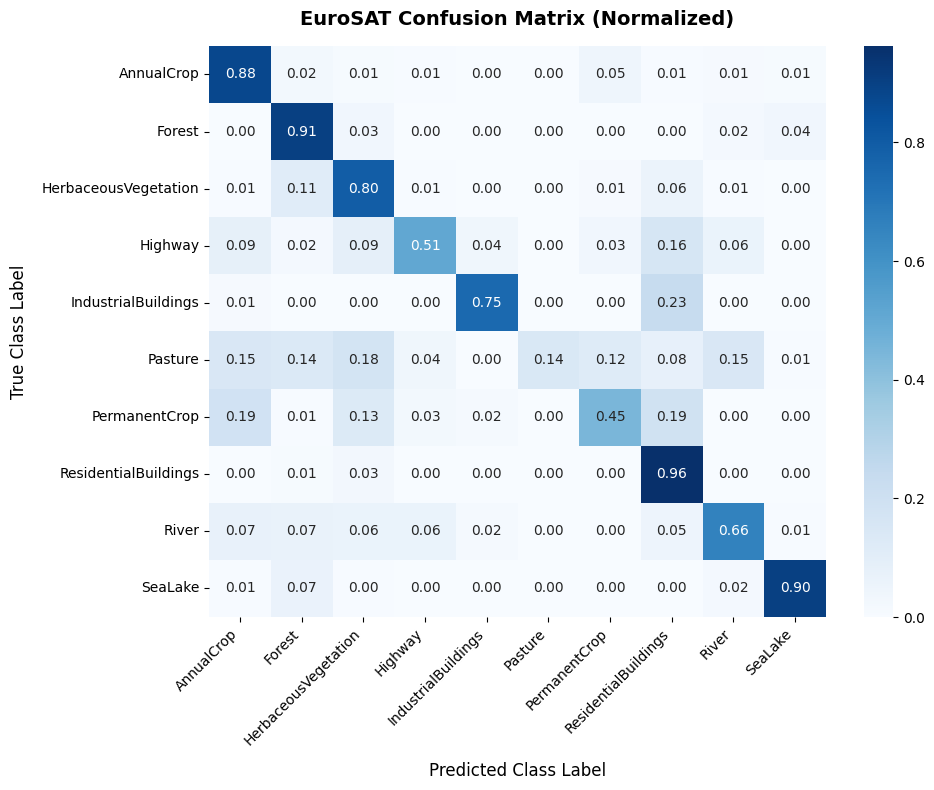

/tmp/ipykernel_775/2306148812.py:189: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=f1_scores, palette="viridis")


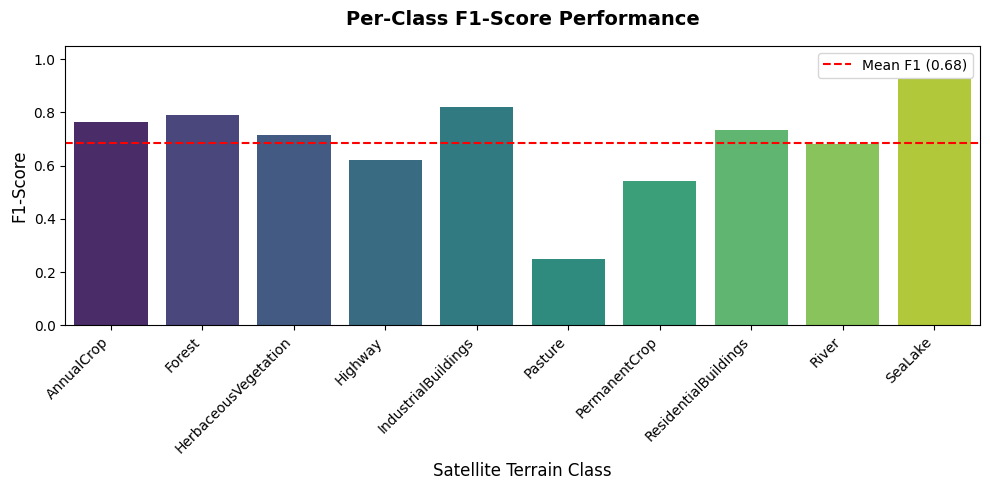

💾 F1-Score chart saved as 'per_class_f1_scores.png'


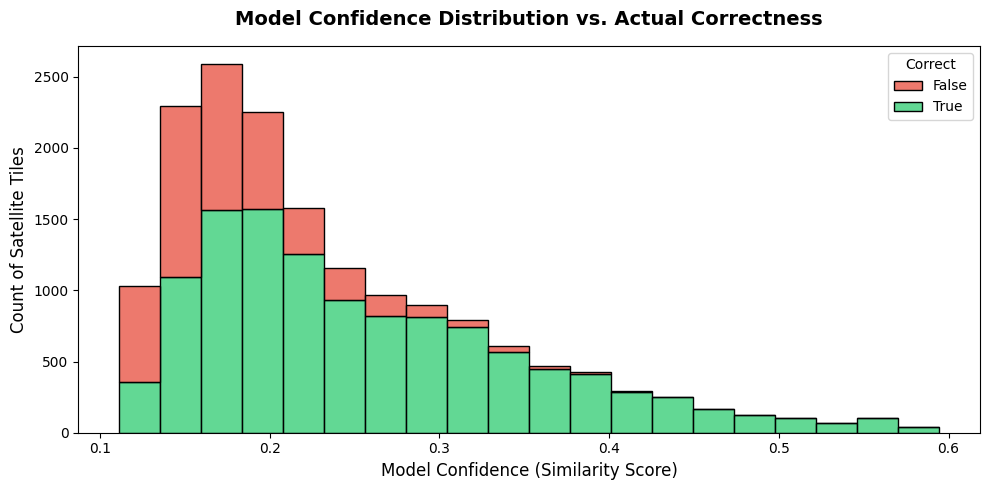

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import open_clip
from peft import LoraConfig, get_peft_model
from tqdm import tqdm
from pathlib import Path
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

!pip install --upgrade torchao

class LoRASatelliteClassifier(nn.Module):
    def __init__(self, clip_model, num_classes: int = 10):
        super().__init__()
        # Isolate the underlying Vision Transformer Tower from CLIP
        self.vision_encoder = clip_model.visual

        # Configure LoRA to hook into the self-attention projection matrices
        # In OpenCLIP ViT architectures, the attention projection layer is typically 'out_proj' or 'in_proj'
        lora_config = LoraConfig(
            r=16,
            lora_alpha=32,
            target_modules=["out_proj", "in_proj"],
            lora_dropout=0.05,
            bias="none"
        )

        # Wrap the vision encoder with LoRA adapters
        self.peft_vision_encoder = get_peft_model(self.vision_encoder, lora_config)

        # Add a standard classification head on top
        self.classifier_head = nn.Linear(512, num_classes)

    def forward(self, x):
        embeddings = self.peft_vision_encoder(x)
        embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)

        return self.classifier_head(embeddings)

def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    data_directory = "satellite_dataset"
    batch_size = 32
    epochs = 5
    lr = 3e-4

    #  Load Core Model and Visual Transforms
    base_model, _, preprocess = open_clip.create_model_and_transforms(
        'ViT-B-32', pretrained='laion2b_s34b_b79k', device=device)

    # Setup Dataset Split
    full_dataset = ImageFolder(root=data_directory, transform=preprocess)
    num_classes = len(full_dataset.classes)

    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    # Instantiate LoRA Network Architecture,optimise and schedule
    model = LoRASatelliteClassifier(base_model, num_classes=num_classes).to(device)
    model.peft_vision_encoder.print_trainable_parameters()
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=0.01)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss().to(device)

    # Initialize lists to store predictions for evaluation metrics
    all_targets = []
    all_predictions = []
    all_confidences = []
    all_correctness = []

    # Fine-Tuning Execution Loop
    print(f"\n🚀 Initiating Vision Tower Parameter Fine-Tuning on {device}...")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        scheduler.step()

        # Validation Pass
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                predictions = outputs.argmax(dim=-1)

                # Collect predictions and targets for overall metrics
                all_targets.extend(labels.cpu().numpy())
                all_predictions.extend(predictions.cpu().numpy())

                # Calculate confidence (max probability) and correctness
                probabilities = torch.nn.functional.softmax(outputs, dim=-1)
                all_confidences.extend(probabilities.max(dim=-1).values.cpu().numpy())
                all_correctness.extend((predictions == labels).cpu().numpy())

                correct += (predictions == labels).sum().item()
                total += labels.size(0)

        epoch_acc = (correct / total) * 100
        print(f"📉 Epoch {epoch+1:02d} Loss: {running_loss/len(train_loader):.4f} | ✨ Val Accuracy: {epoch_acc:.2f}%")

    # Convert lists to numpy arrays for sklearn metrics
    all_targets = np.array(all_targets)
    all_predictions = np.array(all_predictions)
    all_confidences = np.array(all_confidences)
    all_correctness = np.array(all_correctness)


    classes = full_dataset.classes

    # Compute and normalize the matrix
    cm = confusion_matrix(all_targets, all_predictions)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Compute classification report and extract per class F1 score
    report_dict = classification_report(all_targets, all_predictions, target_names=classes, output_dict=True)
    f1_scores = [report_dict[cls]['f1-score'] for cls in classes]

    # Detailed metrics for global macro-averaging
    TP = np.diag(cm)
    FP = np.sum(cm, axis=0) - TP
    FN = np.sum(cm, axis=1) - TP

    # Adding a small epsilon (1e-7) prevents "division by zero" errors
    class_precision = TP / (TP + FP + 1e-7)
    class_recall    = TP / (TP + FN + 1e-7) # Equivalent to Sensitivity
    class_f1        = 2 * (class_precision * class_recall) / (class_precision + class_recall + 1e-7)

    # --- Global Macro-Averaging ---
    # Accuracy needs total correct / total samples
    total_correct = np.sum(all_correctness)
    total_samples = len(all_targets)
    accuracy = total_correct / total_samples

    precision = np.mean(class_precision)
    recall    = np.mean(class_recall)
    f1        = np.mean(class_f1)

    print(f"Accuracy: {accuracy:.4f}") # Overall match
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    # Create the heatmap plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes,
        cbar=True
    )

    plt.title("EuroSAT Confusion Matrix (Normalized)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Predicted Class Label", fontsize=12, labelpad=10)
    plt.ylabel("True Class Label", fontsize=12, labelpad=10)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Plot F1-Scores
    plt.figure(figsize=(10, 5))
    sns.barplot(x=classes, y=f1_scores, palette="viridis")
    plt.axhline(y=np.mean(f1_scores), color='r', linestyle='--', label=f'Mean F1 ({np.mean(f1_scores):.2f})')
    plt.title("Per-Class F1-Score Performance", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Satellite Terrain Class", fontsize=12)
    plt.ylabel("F1-Score", fontsize=12)
    plt.ylim(0, 1.05)
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()
    print("💾 F1-Score chart saved as 'per_class_f1_scores.png'")

    # Plot Confidence Distribution broken down by True vs False predictions
    plt.figure(figsize=(10, 5))
    df_perf = {"Confidence": all_confidences, "Correct": all_correctness}
    sns.histplot(data=df_perf, x="Confidence", hue="Correct", multiple="stack", bins=20, palette={True: "#2ecc71", False: "#e74c3c"})
    plt.title("Model Confidence Distribution vs. Actual Correctness", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Model Confidence (Similarity Score)", fontsize=12)
    plt.ylabel("Count of Satellite Tiles", fontsize=12)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()
